# FINE vs ETAS across forecast horizons

Same catalog, same FINE checkpoint, different forecast lengths for the Hauksson pre-Ridgecrest test (2016-05-23 → 2019-07-01). Two output roots:

- `outputs/rolling_continuation_hauksson_pre_ridgecrest_short` — `horizon_0.5d`, `horizon_1d`
- `outputs/rolling_continuation_hauksson_pre_ridgecrest` — `horizon_7d`, `horizon_60d`, `horizon_300d`

The next cell runs `runnable_code/cache_horizon_comparison.py` for each root. That script fills each horizon's analysis cache — the scores, window tests, intensity grids, and catalogs used by `compare_rolling_etas_fine_horizon_bayona.ipynb` — and writes comparison tables under `<output_root>/horizon_comparison/`. With `n_realizations=None`, every seed that has both etas and FINE catalogs on all steps is cached (no seed cap).

A repeat run only computes new or changed realizations. Window tests for a horizon are recomputed when its seed list changes. Pass `--force` only to rebuild comparison tables and window tests; intensity grids are still reused when forecast files are unchanged.

Other notebooks load the same tables without recomputing:

```python
import etas.horizon_comparison as horizon_comparison
comparison = horizon_comparison.load_comparison(output_root)
comparison.summary
comparison.scores
comparison.analysis(1.0)   # grids and catalogs for one horizon
```


In [2]:
%matplotlib inline
from __future__ import annotations

import subprocess
import sys
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

import etas.horizon_comparison as horizon_comparison
import etas.rolling_analysis as rolling_analysis

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "runnable_code" / "cache_horizon_comparison.py").is_file():
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    else:
        for parent in REPO_ROOT.parents:
            if (parent / "runnable_code" / "cache_horizon_comparison.py").is_file():
                REPO_ROOT = parent
                break

# n_realizations=None → every seed present for both methods on every step.
# from_cache=True → load existing analysis only (fast). Run cache_horizon_comparison
# in the shell when new forecast catalogs appear; then re-run this cell.
EXPERIMENTS = [
    {
        "output_root": REPO_ROOT / "outputs/rolling_continuation_hauksson_pre_ridgecrest_short",
        "config": REPO_ROOT / "config/rolling_continuation_hauksson_pre_ridgecrest_short.json",
        "horizon_days": [0.5, 1.0],
        "from_cache": True,
        "n_realizations": None,
    },
    {
        "output_root": REPO_ROOT / "outputs/rolling_continuation_hauksson_pre_ridgecrest",
        "config": REPO_ROOT / "config/rolling_continuation_hauksson_pre_ridgecrest.json",
        "horizon_days": [7.0, 60.0, 300.0],
        "from_cache": True,
        "n_realizations": None,
    },
]
METHODS = ["etas", "FINE"]
CSEP_DH = 0.1
BAYONA_N_SIM = 200
METHOD_COLORS = {"etas": "seagreen", "FINE": "mediumpurple"}
METHOD_LABELS = {"etas": "ETAS", "FINE": "FINE"}


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


def _seed_count_span(low: float, high: float) -> str:
    """Format a per-window seed *count* (not seed id range)."""
    low_i, high_i = int(low), int(high)
    if low_i == high_i:
        return f"{low_i} seeds"
    return f"{low_i}–{high_i} seeds/window"


def _model_text(payload: dict) -> str:
    model_dir = Path(str((payload.get("magnet") or {}).get("model_dir") or ""))
    parts = model_dir.parts
    variant = ""
    if "FINE_variants" in parts:
        index = parts.index("FINE_variants") + 1
        if index < len(parts):
            variant = parts[index]
    model_part = next((part for part in parts if part.startswith("model_")), "")
    model_id = model_part.removeprefix("model_")[:12] or model_dir.name
    repetition = next((part for part in parts if part.startswith("_repetition_")), "")
    repetition_n = repetition.removeprefix("_repetition_") if repetition else "0"
    variant_text = f"{variant}, " if variant else ""
    return f"FINE-MAGNET {model_id} ({variant_text}repetition {repetition_n}) and ETAS"


def _dataset_text(payload: dict) -> str:
    catalog = Path(str(payload.get("fn_catalog") or "")).name
    region = str(payload.get("region") or "")
    name = "Hauksson" if "hauksson" in catalog.lower() else catalog
    mc = payload.get("mc")
    mc_text = f", Mc {float(mc):g}" if isinstance(mc, (int, float)) else ""
    region_text = f", {region.capitalize()}" if region else ""
    start = str(payload.get("timewindow_end") or "")[:10]
    end = str(payload.get("testwindow_end") or "")[:10]
    span = f", forecasts {start} to {end}" if start and end else ""
    return f"{name}{region_text} ({catalog}){mc_text}{span}"


def _unique_config_text(reader) -> str:
    labels: list[str] = []
    for experiment in EXPERIMENTS:
        payload = json.loads(Path(experiment["config"]).read_text(encoding="utf-8"))
        label = reader(payload)
        if label not in labels:
            labels.append(label)
    return "; ".join(labels)


def _disk_realization_span(output_root: Path, horizon_days: float, method: str) -> str:
    horizon_dir = rolling_analysis.horizon_directory(output_root, horizon_days)
    counts = [
        len(rolling_analysis._forecast_files(step_dir, method))
        for _index, step_dir in rolling_analysis._discover_steps(horizon_dir)
    ]
    if not counts:
        return "0 seeds"
    return _seed_count_span(min(counts), max(counts))


def _loaded_realization_span(scores: pd.DataFrame, horizon_days: float, method: str) -> str:
    if scores.empty or "n_seeds" not in scores.columns:
        return "0 seeds"
    mask = np.isclose(scores["horizon_days"].to_numpy(dtype=float), float(horizon_days))
    values = pd.to_numeric(
        scores.loc[mask & (scores["method"] == method), "n_seeds"],
        errors="coerce",
    ).dropna()
    if values.empty:
        return "0 seeds"
    return _seed_count_span(float(values.min()), float(values.max()))


script = REPO_ROOT / "runnable_code" / "cache_horizon_comparison.py"
summaries = []
score_frames = []
for experiment in EXPERIMENTS:
    if experiment["from_cache"]:
        # Read tables only — do not call the cache script (it takes an exclusive
        # flock on horizon_comparison/.lock and blocks behind any refresh job).
        print(f"from_cache: {experiment['output_root']}", flush=True)
        loaded = horizon_comparison.load_comparison(experiment["output_root"])
    else:
        command = [
            sys.executable,
            str(script),
            "--output-root", str(experiment["output_root"]),
            "--config", str(experiment["config"]),
            "--repo-root", str(REPO_ROOT),
            "--horizon-days", *[str(days) for days in experiment["horizon_days"]],
            "--dh", str(CSEP_DH),
            "--num-simulations", str(BAYONA_N_SIM),
            "--methods", *METHODS,
        ]
        if experiment["n_realizations"] is not None:
            command.extend(["--n-realizations", str(experiment["n_realizations"])])
        process = subprocess.Popen(
            command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
        )
        assert process.stdout is not None
        for line in process.stdout:
            print(line, end="", flush=True)
        return_code = process.wait()
        if return_code != 0:
            raise RuntimeError(f"comparison cache script exited {return_code}")
        loaded = horizon_comparison.load_comparison(experiment["output_root"])
    summaries.append(loaded.summary)
    score_frames.append(loaded.scores.assign(_output_root=str(experiment["output_root"])))

summary = pd.concat(summaries, ignore_index=True)
summary = summary.sort_values(["horizon_days", "method"]).reset_index(drop=True)
scores = pd.concat(score_frames, ignore_index=True) if score_frames else pd.DataFrame()
coverage = summary.drop_duplicates("horizon_days")[
    ["horizon_days", "n_steps_cached", "n_steps_on_disk", "n_seeds"]
]

rows = []
for days in coverage["horizon_days"]:
    days = float(days)
    experiment = next(
        item for item in EXPERIMENTS
        if any(np.isclose(days, float(value)) for value in item["horizon_days"])
    )
    window_rows = summary.loc[np.isclose(summary["horizon_days"], days)]
    rows.append({
        "Horizon": f"{days:g} d",
        "Windows loaded": int(window_rows["n_steps_cached"].iloc[0]),
        "Windows total": int(window_rows["n_steps_on_disk"].iloc[0]),
        "ETAS loaded": _loaded_realization_span(scores, days, "etas"),
        "ETAS on disk": _disk_realization_span(experiment["output_root"], days, "etas"),
        "FINE loaded": _loaded_realization_span(scores, days, "FINE"),
        "FINE on disk": _disk_realization_span(experiment["output_root"], days, "FINE"),
    })
loaded_table = pd.DataFrame(rows)
loaded_table.columns = pd.MultiIndex.from_tuples([
    ("", "Horizon"),
    ("Windows", "Loaded"),
    ("Windows", "Total"),
    ("ETAS seed count", "In cache"),
    ("ETAS seed count", "On disk"),
    ("FINE seed count", "In cache"),
    ("FINE seed count", "On disk"),
])
display(Markdown(
    f"**Model:** {_unique_config_text(_model_text)}\n\n"
    f"**Dataset:** {_unique_config_text(_dataset_text)}\n\n"
    "Cells are **counts of seeds per window** (not seed id ranges). "
    "A value like `3–9 seeds/window` means the count varies across windows; "
    "`30 seeds` means every window has that many. "
    "In cache = catalogs in the analysis scores; on disk = forecast catalogs present."
))
display(HTML(loaded_table.to_html(index=False)))


from_cache: /home/neriberman/Repos/etas/outputs/rolling_continuation_hauksson_pre_ridgecrest_short
from_cache: /home/neriberman/Repos/etas/outputs/rolling_continuation_hauksson_pre_ridgecrest


**Model:** FINE-MAGNET 9e2618ba2630 (mc_depth, repetition 0) and ETAS

**Dataset:** Hauksson, California (etas_converted_hauksson.csv), Mc 2.4, forecasts 2016-05-23 to 2019-07-01

Cells are **counts of seeds per window** (not seed id ranges). A value like `3–9 seeds/window` means the count varies across windows; `30 seeds` means every window has that many. In cache = catalogs in the analysis scores; on disk = forecast catalogs present.

## Metrics vs forecast horizon

One line per method for each scalar that the Bayona single-horizon notebook summarizes. Values come from the comparison cache (`summary.csv` and per-window `scores.csv`). The cumulative number test is the Bayona Fig. 3c comparison across horizons: black points are expected totals, colored points are the observed total (coolwarm by percentage discrepancy), solid bars are Poisson 95% intervals, and dashed bars are negative-binomial 95% intervals. Per-window ζ is shown as violins at each horizon (methods offset); the consistency fraction is still the share of windows with ζ ≥ 0.05. Consistency fractions use the 95% thresholds from that notebook. ζ calibration area is the integrated gap between the sorted window quantiles and Uniform(0, 1).

FINE-against-ETAS scalars (one line, not one per method) are in the next section.


,horizon_days,method,n_forecast,n_observed,delta_percent,poisson_low,poisson_high,nbd_low,nbd_high,catalog_variance
0,0.5,FINE,3757.423721,1088.0,71.043990,3638.0,3878.0,5.0,18451.0,2.685809e+07
1,0.5,etas,2052.705449,1088.0,46.996779,1964.0,2142.0,1070.0,3348.0,3.424806e+05
2,1.0,FINE,3146.247503,1088.0,65.419122,3037.0,3257.0,24.0,13323.0,1.355971e+07
3,1.0,etas,3110.545358,1088.0,65.022211,3002.0,3220.0,2094.0,4324.0,3.253048e+05
4,7.0,FINE,974.806271,1088.0,10.403835,914.0,1036.0,74.0,3002.0,6.150068e+05
5,7.0,etas,909.672914,1088.0,16.390357,851.0,969.0,417.0,1589.0,9.099334e+04
6,60.0,FINE,1151.422408,1088.0,5.508179,1085.0,1218.0,63.0,3772.0,1.000175e+06
7,60.0,etas,929.083122,1088.0,14.606331,870.0,989.0,666.0,1234.0,2.105851e+04
8,300.0,FINE,1072.704722,1088.0,1.405816,1009.0,1137.0,186.0,2719.0,4.444291e+05
9,300.0,etas,1067.194505,1088.0,1.912270,1004.0,1132.0,815.0,1352.0,1.884077e+04


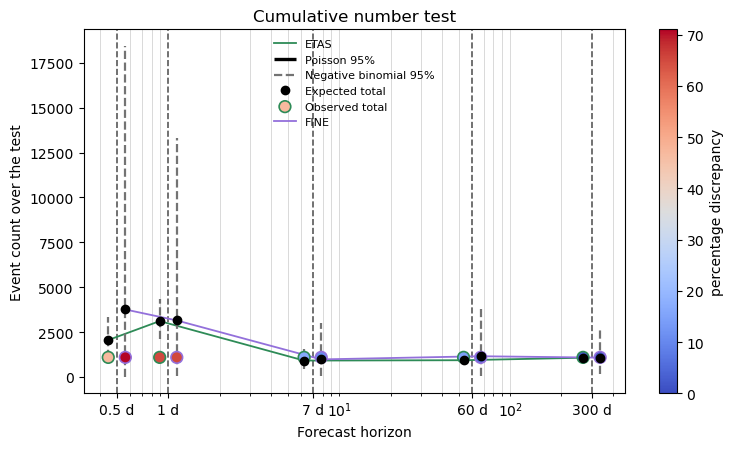

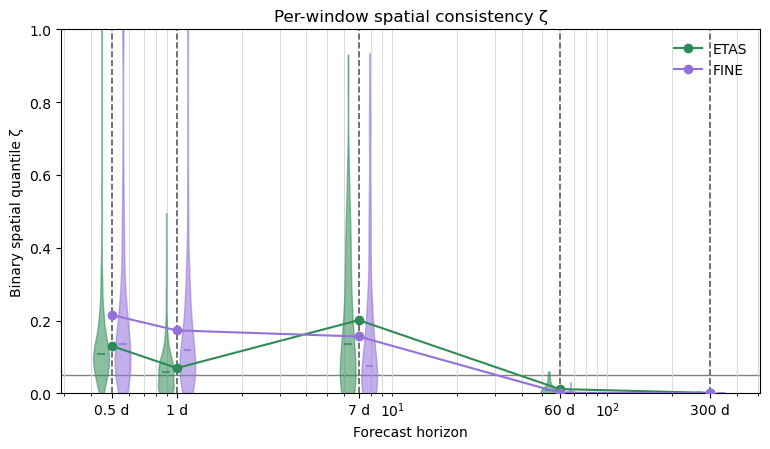

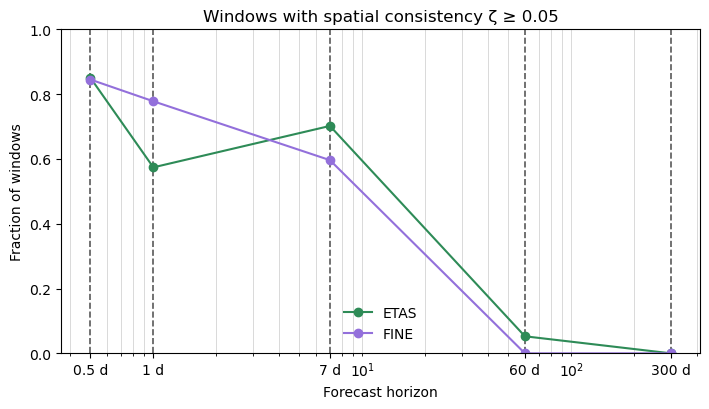

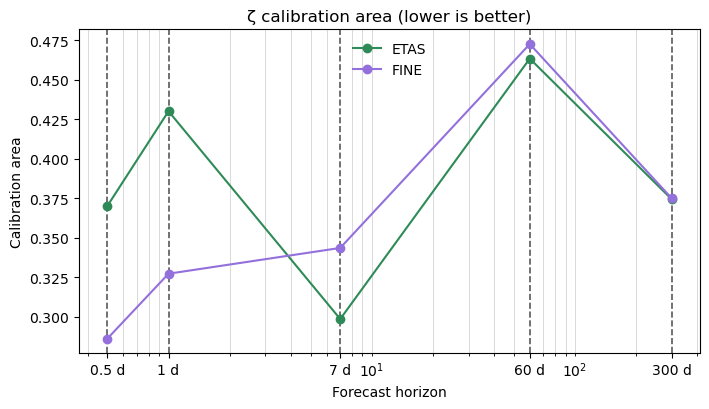

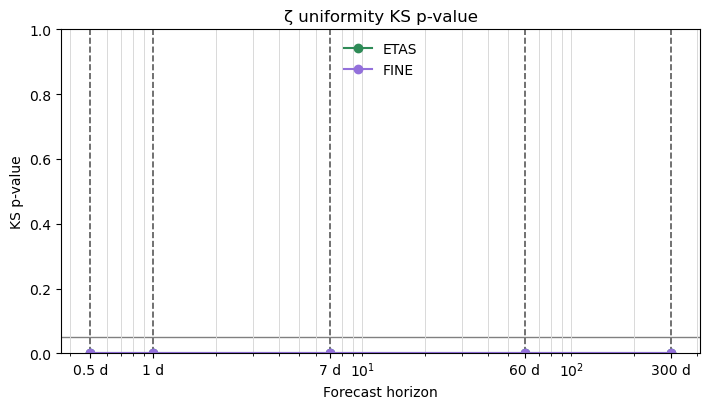

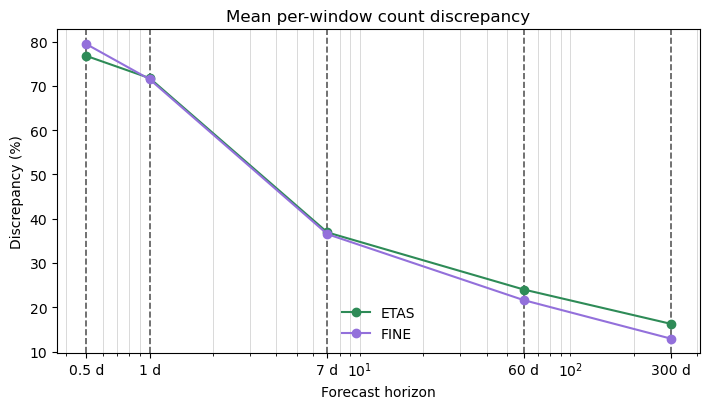

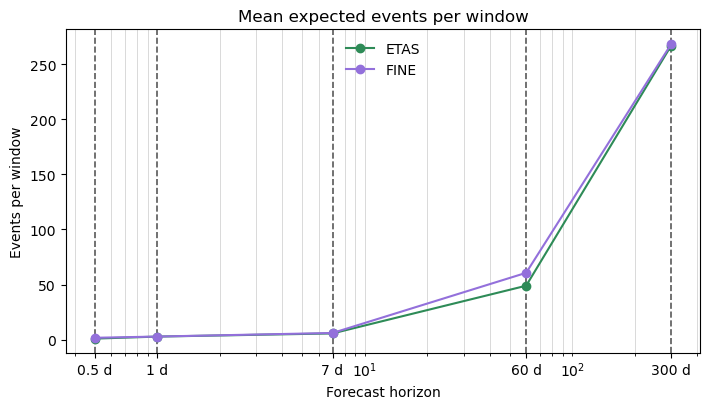

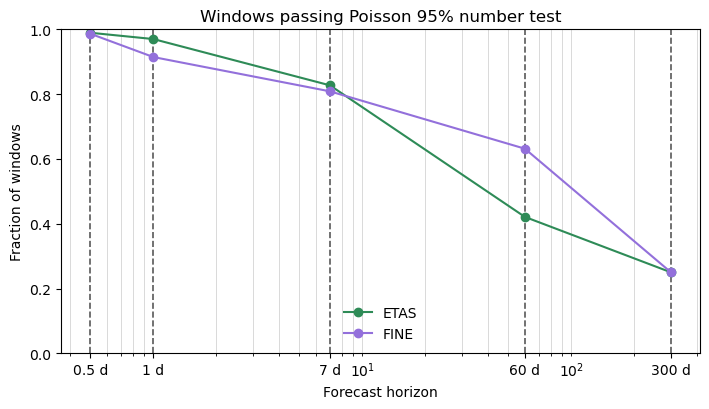

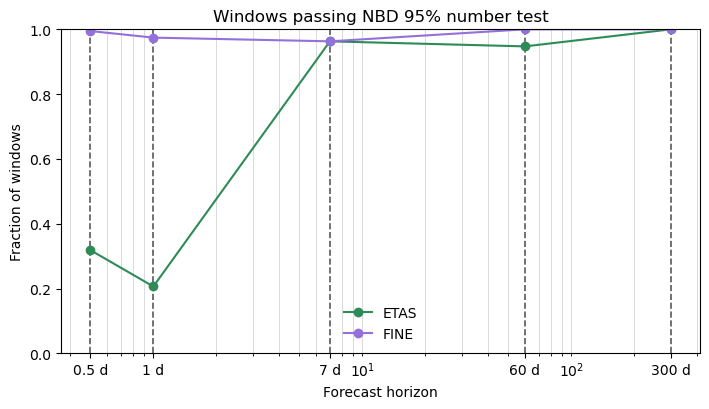

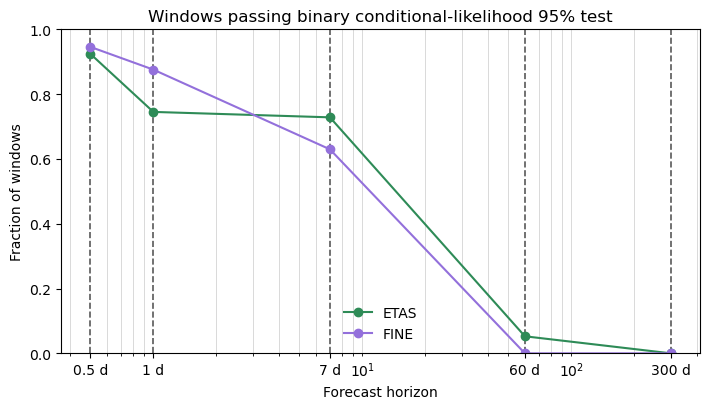

In [3]:
from matplotlib.ticker import FixedFormatter, FixedLocator, LogLocator

import etas.bayona_evaluations as bayona_evaluations

horizons = [float(days) for days in coverage["horizon_days"]]
methods = [method for method in METHODS if method in set(summary["method"])]
partial = bool((coverage["n_steps_cached"] < coverage["n_steps_on_disk"]).any())
partial_note = " (cached windows)" if partial else ""
_LOG_OFFSET = {"etas": -0.05, "FINE": 0.05}


def _style_horizon_axis(ax) -> None:
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(horizons))
    ax.xaxis.set_major_formatter(FixedFormatter([f"{days:g} d" for days in horizons]))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1, 10)))
    ax.grid(True, which="minor", axis="x", color="0.85", linestyle="-", linewidth=0.7, zorder=0)
    for days in horizons:
        ax.axvline(days, color="0.35", linestyle="--", linewidth=1.2, zorder=1)
    ax.set_xlabel("Forecast horizon")


def _horizon_x(days: float, method: str) -> float:
    return float(days) * (10.0 ** _LOG_OFFSET.get(method, 0.0))


def plot_metric_vs_horizon(
    frame: pd.DataFrame,
    metric: str,
    *,
    title: str,
    ylabel: str,
    ylim: tuple[float, float] | None = None,
    methods_to_plot: list[str] | None = None,
    hline: float | None = None,
) -> None:
    plot_methods = methods_to_plot or methods
    indexed = frame.set_index(["horizon_days", "method"])
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    _style_horizon_axis(ax)
    if hline is not None:
        ax.axhline(hline, color="0.5", linewidth=1.0, zorder=1)
    for method in plot_methods:
        heights = [
            float(indexed.loc[(days, method), metric])
            if (days, method) in indexed.index else np.nan
            for days in horizons
        ]
        ax.plot(
            horizons,
            heights,
            color=METHOD_COLORS.get(method),
            marker="o",
            label=METHOD_LABELS.get(method, method),
            zorder=2,
        )
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(title + partial_note)
    ax.legend(frameon=False)
    fig.tight_layout()
    show_fig(fig)


def plot_zeta_violin_vs_horizon(window_scores: pd.DataFrame) -> None:
    """Per-window binary spatial ζ as violins at each forecast horizon."""
    if window_scores.empty or "zeta" not in window_scores.columns:
        display(Markdown("*Skipped ζ violin: no per-window ζ in the loaded scores.*"))
        return
    fig, ax = plt.subplots(figsize=(7.8, 4.6))
    ax.axhline(0.05, color="0.5", linewidth=1.0, zorder=1)
    mean_days: dict[str, list[float]] = {method: [] for method in methods}
    mean_ys: dict[str, list[float]] = {method: [] for method in methods}
    for method in methods:
        color = METHOD_COLORS.get(method)
        for days in horizons:
            group = window_scores.loc[
                np.isclose(window_scores["horizon_days"].to_numpy(dtype=float), days)
                & (window_scores["method"] == method),
                "zeta",
            ]
            values = pd.to_numeric(group, errors="coerce").to_numpy(dtype=float)
            values = values[np.isfinite(values)]
            if values.size < 2:
                continue
            position = _horizon_x(days, method)
            # Width scales with x so violins stay readable on a log axis.
            width = position * (10.0 ** 0.035 - 1.0) * 2.0
            parts = ax.violinplot(
                [values],
                positions=[position],
                widths=[width],
                showmeans=False,
                showmedians=True,
                showextrema=False,
            )
            for body in parts["bodies"]:
                body.set_facecolor(color)
                body.set_edgecolor(color)
                body.set_alpha(0.55)
                body.set_zorder(2)
            for key in ("cmeans", "cmedians", "cbars", "cmins", "cmaxes"):
                if key in parts:
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.1)
            mean_days[method].append(float(days))
            mean_ys[method].append(float(np.mean(values)))
    for method in methods:
        if not mean_days[method]:
            continue
        color = METHOD_COLORS.get(method)
        # Same x positions as the other metric line plots (exact horizon ticks).
        ax.plot(
            mean_days[method],
            mean_ys[method],
            color=color,
            marker="o",
            zorder=3,
            label=METHOD_LABELS.get(method, method),
        )
    # violinplot can reset the x scale; restore the shared horizon axis last.
    _style_horizon_axis(ax)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("Binary spatial quantile ζ")
    ax.set_title("Per-window spatial consistency ζ" + partial_note)
    ax.legend(frameon=False)
    fig.tight_layout()
    show_fig(fig)


def _catalog_size_variance(store, method: str) -> float:
    sizes = np.array(
        [len(store.event_frame(method, seed)) for seed in store.seeds],
        dtype=float,
    )
    if sizes.size < 2:
        return float("nan")
    return float(np.var(sizes, ddof=1))


def build_cumulative_number_table() -> pd.DataFrame:
    """Expected totals, Poisson / NBD intervals, and percentage discrepancy."""
    rows: list[dict] = []
    for experiment in EXPERIMENTS:
        comparison = horizon_comparison.load_comparison(experiment["output_root"])
        for days in experiment["horizon_days"]:
            days = float(days)
            try:
                store = comparison.analysis(days)
            except FileNotFoundError:
                continue
            horizon_scores = store.scores
            if horizon_scores.empty:
                continue
            observed_total = float(
                horizon_scores.drop_duplicates("step_index")["n_observed"].sum()
            )
            for method in methods:
                group = horizon_scores.loc[horizon_scores["method"] == method]
                if group.empty:
                    continue
                n_forecast = float(group["n_forecast"].sum())
                poisson_low, poisson_high = bayona_evaluations.fmd_poisson_intervals(
                    np.array([n_forecast]),
                )
                variance = _catalog_size_variance(store, method)
                nbd = bayona_evaluations.negative_binomial_interval(n_forecast, variance)
                rows.append({
                    "horizon_days": days,
                    "method": method,
                    "n_forecast": n_forecast,
                    "n_observed": observed_total,
                    "delta_percent": bayona_evaluations.count_discrepancy(
                        n_forecast, observed_total,
                    ),
                    "poisson_low": float(poisson_low[0]),
                    "poisson_high": float(poisson_high[0]),
                    "nbd_low": np.nan if nbd is None else float(nbd[0]),
                    "nbd_high": np.nan if nbd is None else float(nbd[1]),
                    "catalog_variance": variance,
                })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["horizon_days", "method"]).reset_index(drop=True)


def plot_cumulative_number_vs_horizon(table: pd.DataFrame) -> None:
    """Bayona Fig. 3c quantities vs horizon: intervals as vertical bars."""
    if table.empty:
        display(Markdown("*Skipped cumulative number test: no analysis caches loaded.*"))
        return
    fig, ax = plt.subplots(figsize=(7.8, 4.6))
    _style_horizon_axis(ax)
    poisson_labeled = False
    nbd_labeled = False
    expected_labeled = False
    delta_max = max(float(np.nanmax(table["delta_percent"].to_numpy(dtype=float))), 1.0)
    observed = None
    for method in methods:
        sub = table.loc[table["method"] == method]
        if sub.empty:
            continue
        x = np.array([_horizon_x(days, method) for days in sub["horizon_days"]], dtype=float)
        ax.plot(
            x,
            sub["n_forecast"].to_numpy(dtype=float),
            color=METHOD_COLORS.get(method),
            lw=1.3,
            zorder=2,
            label=METHOD_LABELS.get(method, method),
        )
        for xi, row in zip(x, sub.itertuples(index=False)):
            ax.plot(
                [xi, xi],
                [row.poisson_low, row.poisson_high],
                color="black",
                lw=2.4,
                solid_capstyle="butt",
                zorder=3,
                label="Poisson 95%" if not poisson_labeled else None,
            )
            poisson_labeled = True
            if np.isfinite(row.nbd_low) and np.isfinite(row.nbd_high):
                ax.plot(
                    [xi, xi],
                    [row.nbd_low, row.nbd_high],
                    color="0.45",
                    lw=1.6,
                    ls="--",
                    solid_capstyle="butt",
                    zorder=3,
                    label="Negative binomial 95%" if not nbd_labeled else None,
                )
                nbd_labeled = True
        ax.plot(
            x,
            sub["n_forecast"].to_numpy(dtype=float),
            "o",
            color="black",
            ms=6,
            zorder=5,
            label="Expected total" if not expected_labeled else None,
        )
        expected_labeled = True
        observed = ax.scatter(
            x,
            sub["n_observed"].to_numpy(dtype=float),
            c=sub["delta_percent"].to_numpy(dtype=float),
            cmap="coolwarm",
            s=70,
            zorder=4,
            vmin=0.0,
            vmax=delta_max,
            edgecolors=METHOD_COLORS.get(method),
            linewidths=1.2,
            label="Observed total" if method == methods[0] else None,
        )
    if observed is not None:
        fig.colorbar(observed, ax=ax, label="percentage discrepancy")
    ax.set_ylabel("Event count over the test")
    ax.set_title("Cumulative number test" + partial_note)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    show_fig(fig)


plot_summary = summary.copy()
plot_summary["mean_n_forecast"] = plot_summary["total_forecast"] / plot_summary["n_windows"]
plot_summary["mean_n_observed"] = plot_summary["total_observed"] / plot_summary["n_windows"]

calibration_rows = []
igpa_rows = []
if not scores.empty:
    for (days, method), group in scores.groupby(["horizon_days", "method"], sort=False):
        zeta = pd.to_numeric(group["zeta"], errors="coerce").to_numpy(dtype=float)
        zeta = zeta[np.isfinite(zeta)]
        if zeta.size:
            calibration = bayona_evaluations.quantile_calibration(zeta)
            calibration_rows.append({
                "horizon_days": float(days),
                "method": method,
                "zeta_calibration_area": float(calibration["area"]),
                "zeta_ks_pvalue": float(calibration["ks_pvalue"]),
            })
        if "IGPA" in group.columns:
            igpa = pd.to_numeric(group["IGPA"], errors="coerce")
            if igpa.notna().any():
                igpa_rows.append({
                    "horizon_days": float(days),
                    "method": method,
                    "cumulative_igpa": float(igpa.sum()),
                })
if calibration_rows:
    plot_summary = plot_summary.merge(
        pd.DataFrame(calibration_rows), on=["horizon_days", "method"], how="left",
    )
if igpa_rows:
    plot_summary = plot_summary.merge(
        pd.DataFrame(igpa_rows), on=["horizon_days", "method"], how="left",
    )

cumulative_number = build_cumulative_number_table()
display(cumulative_number)
plot_cumulative_number_vs_horizon(cumulative_number)
plot_zeta_violin_vs_horizon(scores)

metric_specs = [
    {
        "metric": "fraction_zeta_ge_0.05",
        "title": "Windows with spatial consistency ζ ≥ 0.05",
        "ylabel": "Fraction of windows",
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "zeta_calibration_area",
        "title": "ζ calibration area (lower is better)",
        "ylabel": "Calibration area",
    },
    {
        "metric": "zeta_ks_pvalue",
        "title": "ζ uniformity KS p-value",
        "ylabel": "KS p-value",
        "ylim": (0.0, 1.0),
        "hline": 0.05,
    },
    {
        "metric": "mean_delta_percent",
        "title": "Mean per-window count discrepancy",
        "ylabel": "Discrepancy (%)",
    },
    {
        "metric": "mean_n_forecast",
        "title": "Mean expected events per window",
        "ylabel": "Events per window",
    },
    {
        "metric": "fraction_poisson_consistent_95",
        "title": "Windows passing Poisson 95% number test",
        "ylabel": "Fraction of windows",
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "fraction_nbd_consistent_95",
        "title": "Windows passing NBD 95% number test",
        "ylabel": "Fraction of windows",
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "fraction_binary_cl_consistent_95",
        "title": "Windows passing binary conditional-likelihood 95% test",
        "ylabel": "Fraction of windows",
        "ylim": (0.0, 1.0),
    },
]

for spec in metric_specs:
    metric = spec["metric"]
    if metric not in plot_summary.columns or plot_summary[metric].isna().all():
        display(Markdown(f"*Skipped `{metric}`: not present in the loaded comparison cache.*"))
        continue
    plot_metric_vs_horizon(
        plot_summary,
        metric,
        title=spec["title"],
        ylabel=spec["ylabel"],
        ylim=spec.get("ylim"),
        methods_to_plot=spec.get("methods_to_plot"),
        hline=spec.get("hline"),
    )


## Quantiles inside 0.025–0.975

Share of windows whose quantile falls inside [0.025, 0.975], the same two-sided band as the per-horizon HTML report. Each point is one method at one forecast length.

δ is the Zechar number-test quantile, the Poisson CDF of the mean expected count. ζ is the catalog spatial quantile. Binary ζ is the Bayona activated-cell quantile already stored on each window in `scores.csv`. κ is the Zechar magnitude-test quantile. Windows with a non-finite quantile are left out of the fraction.

The KS plots use the same window quantiles. The statistic is the Kolmogorov–Smirnov distance of the finite values from Uniform(0, 1), the same comparison printed on the per-horizon histograms. A smaller statistic is closer to uniform.

quantiles for 0.5 d
quantiles for 1 d
quantiles for 7 d
quantiles for 60 d
quantiles for 300 d


,horizon_days,method,fraction_delta_inside_band,fraction_zeta_inside_band,fraction_binary_zeta_inside_band,fraction_kappa_inside_band,ks_delta,ks_zeta,ks_binary_zeta,ks_kappa
0,0.5,FINE,0.979709,0.554795,0.893531,0.405660,0.277968,0.410959,0.501846,0.676887
1,0.5,etas,0.973533,0.513514,0.929919,0.566038,0.279423,0.476091,0.663747,0.416442
2,1.0,FINE,0.908289,0.610169,0.881579,0.394737,0.339055,0.279661,0.550789,0.675439
3,1.0,etas,0.966490,0.628205,0.745066,0.547697,0.477010,0.397436,0.770724,0.442434
4,7.0,FINE,0.783951,0.800000,0.788820,0.925466,0.162080,0.163218,0.577298,0.250518
5,7.0,etas,0.808642,0.833333,0.819876,0.944099,0.206257,0.209895,0.450186,0.204141
6,60.0,FINE,0.631579,0.789474,0.052632,0.894737,0.278560,0.215789,0.970000,0.284211
7,60.0,etas,0.368421,0.842105,0.210526,0.894737,0.482756,0.168421,0.940000,0.264912
8,300.0,FINE,0.250000,1.000000,0.000000,1.000000,0.490299,0.683333,1.000000,0.400000
9,300.0,etas,0.250000,1.000000,0.000000,0.750000,0.496229,0.633333,0.995000,0.766667


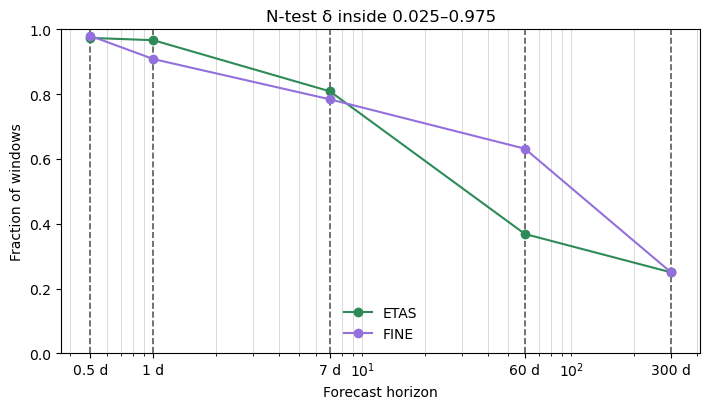

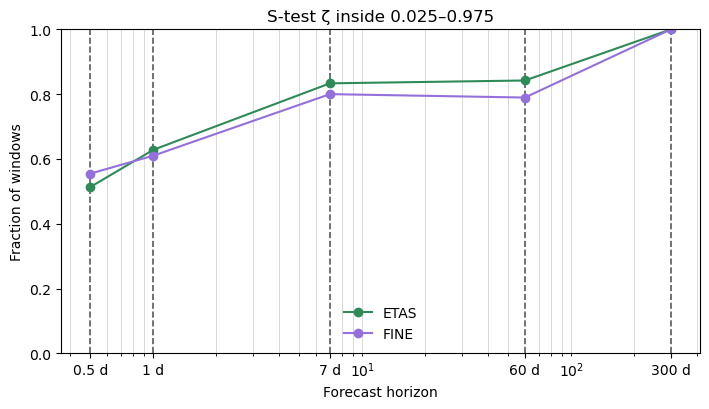

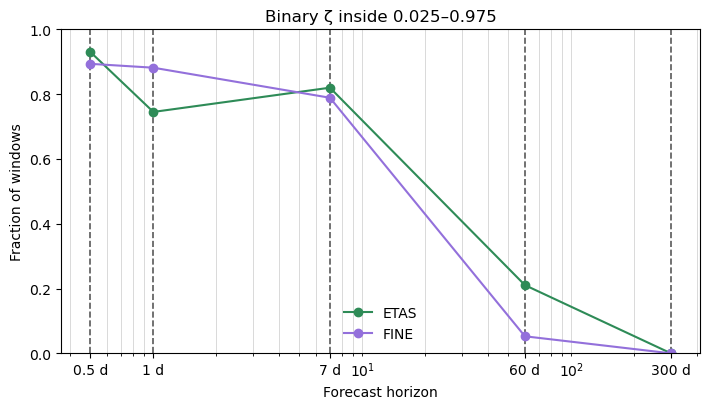

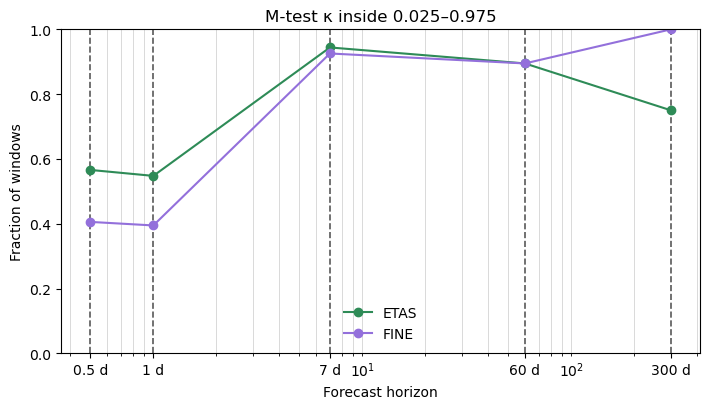

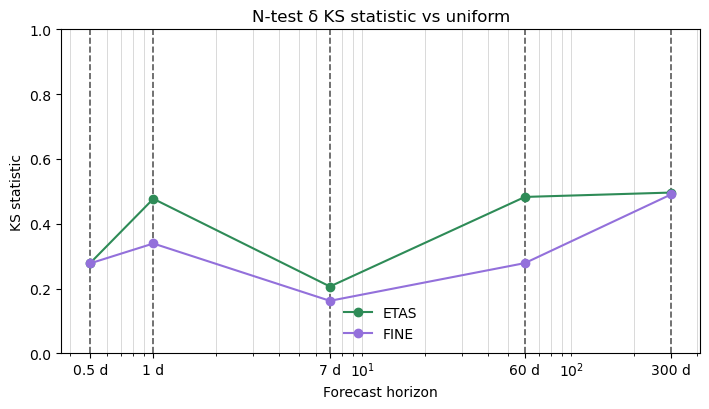

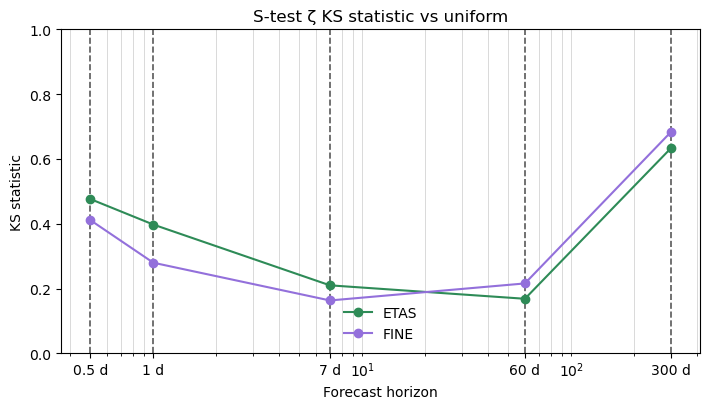

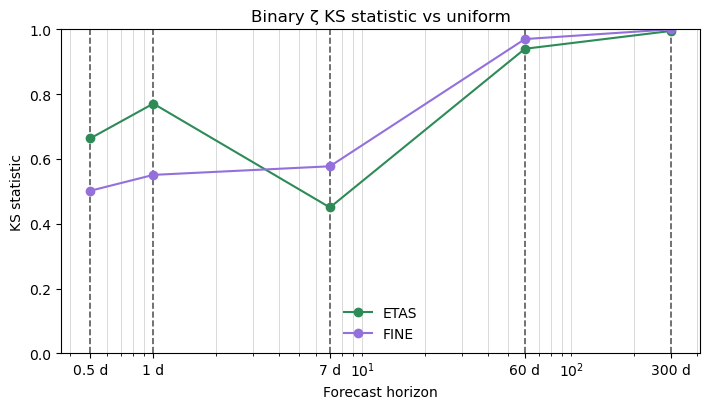

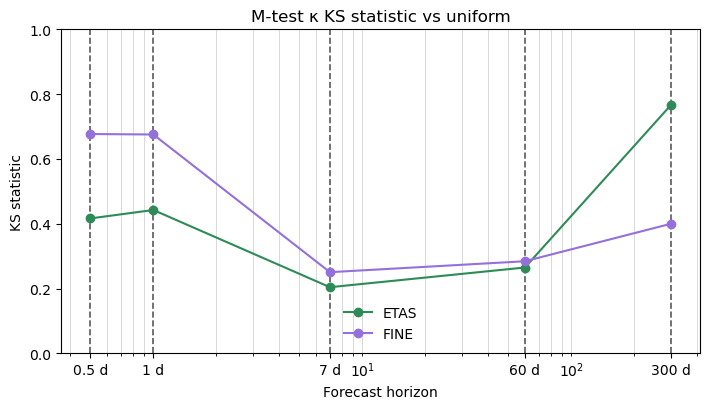

In [4]:
import sys

from scipy import stats as scipy_stats

if str(REPO_ROOT / "runnable_code") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "runnable_code"))

import hauksson_prerc_horizon_report as horizon_report


def _band_fraction(values: pd.Series | np.ndarray) -> float:
    return horizon_report._pass_fraction(np.asarray(values, dtype=float))


def _ks_uniform(values: pd.Series | np.ndarray) -> float:
    """Kolmogorov–Smirnov statistic of the finite quantiles against Uniform(0, 1)."""
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return float("nan")
    return float(scipy_stats.kstest(finite, "uniform").statistic)


def build_quantile_band_table() -> pd.DataFrame:
    """Pass fractions and uniform KS statistics for δ, ζ, binary ζ, and κ."""
    rows: list[dict] = []
    for experiment in EXPERIMENTS:
        comparison = horizon_comparison.load_comparison(experiment["output_root"])
        for days in experiment["horizon_days"]:
            days = float(days)
            try:
                store = comparison.analysis(days)
            except FileNotFoundError:
                continue
            horizon_scores = store.scores
            if horizon_scores.empty:
                continue
            print(f"quantiles for {days:g} d", flush=True)
            m_realizations, s_realizations, *_rest = horizon_report.magnitude_and_spatial_realizations(store)
            kappa = horizon_report.window_quantile(
                m_realizations, "m_statistic", "m_observed", "kappa",
            )
            zeta = horizon_report.window_quantile(
                s_realizations, "s_statistic", "s_observed", "zeta",
            )
            for method in methods:
                scores_method = horizon_scores.loc[horizon_scores["method"] == method]
                if scores_method.empty:
                    continue
                delta_values = scores_method["poisson_delta2"]
                binary_values = scores_method["zeta"]
                kappa_method = kappa.loc[kappa["method"] == method, "kappa"]
                zeta_method = zeta.loc[zeta["method"] == method, "zeta"]
                rows.append({
                    "horizon_days": days,
                    "method": method,
                    "fraction_delta_inside_band": _band_fraction(delta_values),
                    "fraction_zeta_inside_band": _band_fraction(zeta_method),
                    "fraction_binary_zeta_inside_band": _band_fraction(binary_values),
                    "fraction_kappa_inside_band": _band_fraction(kappa_method),
                    "ks_delta": _ks_uniform(delta_values),
                    "ks_zeta": _ks_uniform(zeta_method),
                    "ks_binary_zeta": _ks_uniform(binary_values),
                    "ks_kappa": _ks_uniform(kappa_method),
                })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["horizon_days", "method"]).reset_index(drop=True)


quantile_band = build_quantile_band_table()
display(quantile_band)

band_specs = [
    {
        "metric": "fraction_delta_inside_band",
        "title": "N-test δ inside 0.025–0.975",
        "ylabel": "Fraction of windows",
    },
    {
        "metric": "fraction_zeta_inside_band",
        "title": "S-test ζ inside 0.025–0.975",
        "ylabel": "Fraction of windows",
    },
    {
        "metric": "fraction_binary_zeta_inside_band",
        "title": "Binary ζ inside 0.025–0.975",
        "ylabel": "Fraction of windows",
    },
    {
        "metric": "fraction_kappa_inside_band",
        "title": "M-test κ inside 0.025–0.975",
        "ylabel": "Fraction of windows",
    },
    {
        "metric": "ks_delta",
        "title": "N-test δ KS statistic vs uniform",
        "ylabel": "KS statistic",
    },
    {
        "metric": "ks_zeta",
        "title": "S-test ζ KS statistic vs uniform",
        "ylabel": "KS statistic",
    },
    {
        "metric": "ks_binary_zeta",
        "title": "Binary ζ KS statistic vs uniform",
        "ylabel": "KS statistic",
    },
    {
        "metric": "ks_kappa",
        "title": "M-test κ KS statistic vs uniform",
        "ylabel": "KS statistic",
    },
]
for spec in band_specs:
    plot_metric_vs_horizon(
        quantile_band,
        spec["metric"],
        title=spec["title"],
        ylabel=spec["ylabel"],
        ylim=(0.0, 1.0),
    )


## FINE vs ETAS scalar comparisons

One line per horizon for quantities that compare FINE directly to ETAS (not one line per method). Mean and cumulative IGPA reuse the per-window binary information gain already in `scores.csv` (FINE against ETAS). The binary paired T-test calls PyCSEP `binomial_evaluations.binary_paired_t_test` on each horizon's seed-averaged space–magnitude rates summed over the contiguous walk; the point is information gain per active bin and the whiskers are the 95% interval from that test.


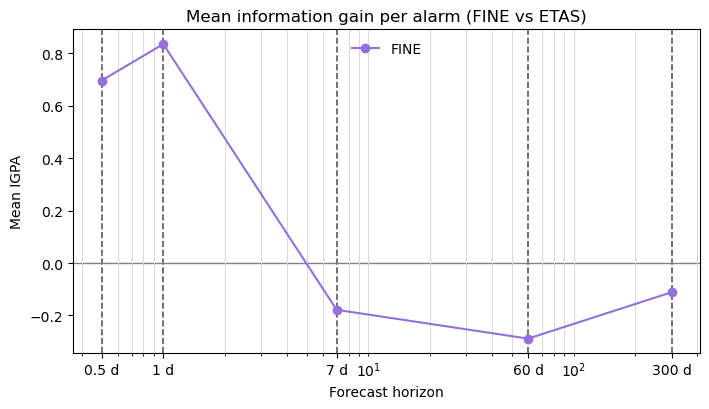

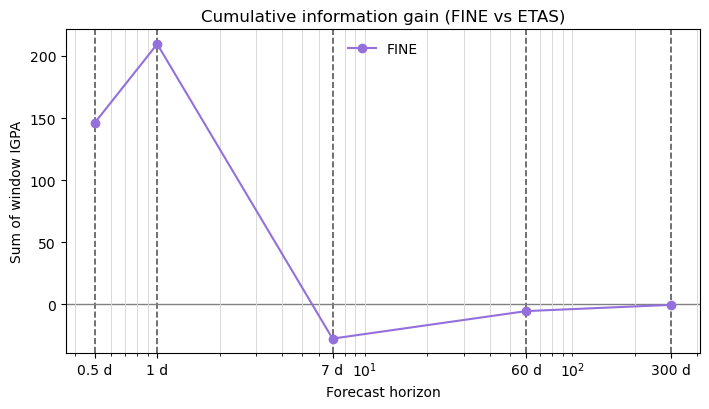

,horizon_days,information_gain,ig_lower,ig_upper,t_statistic,t_critical,n_observed,n_forecast_FINE,n_forecast_etas,significant
0,0.5,-0.146678,-0.201895,-0.091460,-5.214331,1.962975,1088,3757.423721,2052.705449,True
1,1.0,1.779117,1.720063,1.838171,59.138593,1.962975,1088,3146.247503,3110.545358,True
2,7.0,-0.182837,-0.217362,-0.148313,-10.395623,1.962975,1088,974.806271,909.672914,True
3,60.0,-0.348711,-0.390817,-0.306605,-16.256871,1.962975,1088,1151.422408,929.083122,True
4,300.0,-0.075968,-0.134072,-0.017863,-2.566435,1.962975,1088,1072.704722,1067.194505,True


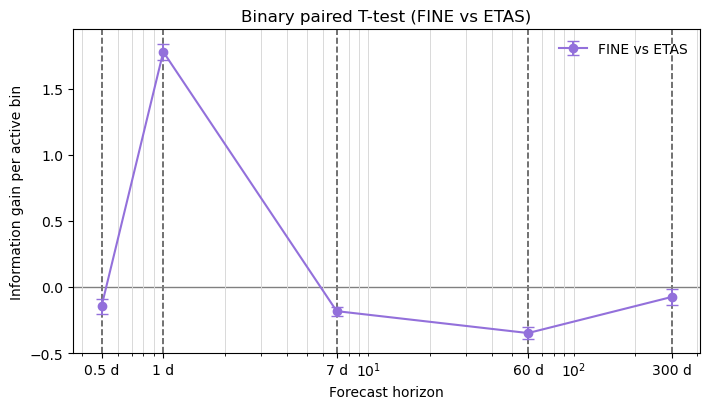

In [5]:
import etas.csep_utils as csep_utils
from csep.core import binomial_evaluations

# PyCSEP binary_paired_t_test / matrix_binary_t_test use ``np`` without importing it.
if not hasattr(binomial_evaluations, "np"):
    binomial_evaluations.np = np

comparison_metric_specs = [
    {
        "metric": "mean_igpa",
        "title": "Mean information gain per alarm (FINE vs ETAS)",
        "ylabel": "Mean IGPA",
        "methods_to_plot": ["FINE"],
        "hline": 0.0,
    },
    {
        "metric": "cumulative_igpa",
        "title": "Cumulative information gain (FINE vs ETAS)",
        "ylabel": "Sum of window IGPA",
        "methods_to_plot": ["FINE"],
        "hline": 0.0,
    },
]

for spec in comparison_metric_specs:
    metric = spec["metric"]
    if metric not in plot_summary.columns or plot_summary[metric].isna().all():
        display(Markdown(f"*Skipped `{metric}`: not present in the loaded comparison cache.*"))
        continue
    plot_metric_vs_horizon(
        plot_summary,
        metric,
        title=spec["title"],
        ylabel=spec["ylabel"],
        ylim=spec.get("ylim"),
        methods_to_plot=spec.get("methods_to_plot"),
        hline=spec.get("hline"),
    )


def build_binary_paired_t_table() -> pd.DataFrame:
    """Horizon-level PyCSEP binary paired T-test of FINE against ETAS."""
    rows: list[dict] = []
    for experiment in EXPERIMENTS:
        comparison = horizon_comparison.load_comparison(experiment["output_root"])
        for days in experiment["horizon_days"]:
            days = float(days)
            try:
                store = comparison.analysis(days)
            except FileNotFoundError:
                continue
            if "FINE" not in store.methods or "etas" not in store.methods:
                continue
            rates = store.mean_rate_grid()
            if "FINE" not in rates or "etas" not in rates:
                display(Markdown(
                    f"*Skipped binary paired T-test at {days:g} d: missing mean rate grids.*"
                ))
                continue
            windows = store.windows()
            if windows.empty:
                continue
            region, study_poly, fit = store.forecast_region()
            start = windows["forecast_start"].min().to_pydatetime()
            end = windows["forecast_end"].max().to_pydatetime()
            forecast_fine = csep_utils.gridded_forecast_from_rates(
                rates["FINE"], region, start, end, METHOD_LABELS.get("FINE", "FINE"),
            )
            forecast_etas = csep_utils.gridded_forecast_from_rates(
                rates["etas"], region, start, end, METHOD_LABELS.get("etas", "ETAS"),
            )
            observed = store.observed_frame().copy()
            if "time" not in observed.columns and "time_days" in observed.columns:
                observed["time"] = (
                    pd.Timestamp("1970-01-01")
                    + pd.to_timedelta(observed["time_days"], unit="D")
                )
            observed = csep_utils.filter_to_csep_region(
                observed,
                region=region,
                m_ref=float(fit["m_ref"]),
                study_poly=study_poly,
            )
            observed_catalog = csep_utils.dataframe_to_csep_catalog(
                observed, catalog_id=int(round(10 * days)), region=region,
            )
            if observed_catalog.event_count < 2:
                display(Markdown(
                    f"*Skipped binary paired T-test at {days:g} d: "
                    f"only {observed_catalog.event_count} observed events.*"
                ))
                continue
            result = binomial_evaluations.binary_paired_t_test(
                forecast_fine, forecast_etas, observed_catalog,
            )
            ig_lower, ig_upper = result.test_distribution
            t_statistic, t_critical = result.quantile
            rows.append({
                "horizon_days": days,
                "information_gain": float(result.observed_statistic),
                "ig_lower": float(ig_lower),
                "ig_upper": float(ig_upper),
                "t_statistic": float(t_statistic),
                "t_critical": float(t_critical),
                "n_observed": int(observed_catalog.event_count),
                "n_forecast_FINE": float(forecast_fine.event_count),
                "n_forecast_etas": float(forecast_etas.event_count),
                "significant": bool(ig_lower > 0.0 or ig_upper < 0.0),
            })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("horizon_days").reset_index(drop=True)


def plot_binary_paired_t_vs_horizon(
    table: pd.DataFrame,
    *,
    title: str = "Binary paired T-test (FINE vs ETAS)",
) -> None:
    """Information gain from a binary T-test table with 95% interval whiskers."""
    if table.empty:
        display(Markdown(f"*Skipped {title}: no analysis caches loaded.*"))
        return
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    _style_horizon_axis(ax)
    ax.axhline(0.0, color="0.5", linewidth=1.0, zorder=1)
    x = table["horizon_days"].to_numpy(dtype=float)
    ig = table["information_gain"].to_numpy(dtype=float)
    yerr = np.vstack([
        ig - table["ig_lower"].to_numpy(dtype=float),
        table["ig_upper"].to_numpy(dtype=float) - ig,
    ])
    color = METHOD_COLORS.get("FINE", "mediumpurple")
    ax.errorbar(
        x, ig, yerr=yerr,
        fmt="o-", color=color, ecolor=color, elinewidth=1.4, capsize=4,
        label="FINE vs ETAS", zorder=2,
    )
    ax.set_ylabel("Information gain per active bin")
    ax.set_title(title + partial_note)
    ax.legend(frameon=False)
    fig.tight_layout()
    show_fig(fig)


binary_paired_t = build_binary_paired_t_table()
display(binary_paired_t)
plot_binary_paired_t_vs_horizon(binary_paired_t)


## CSEP catalog tests and Molchan vs forecast horizon

Same concatenated walk used in the single-horizon Bayona notebook: build a catalog forecast from every cached seed, score it against the observed test catalog, and plot one point per method per horizon.

Deltas follow the usual quantile convention (PL / M / S use δ₂). N-test is shown both as min(δ₁, δ₂) (two-sided consistency) and as δ₂ alone (overprediction tail, same quantile sense as PL/M/S). The Poisson L-test has no δ pair here — the plotted value is γ (fraction of simulated joint log-likelihoods ≤ observed). Molchan uses the area under the miss-rate curve (τ–ν); smaller is better.


CSEP/Molchan T=0.5 d: 29 seeds, 1088 observed events
CSEP/Molchan T=1 d: 12 seeds, 1088 observed events
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1085.0 events after removing 3.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1085.0 events after removing 3.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1087.0 events after removing 1.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1087.0 events after removing 1.0 events.
CSEP/Molchan T=7 d: 30 seeds, 1088 observed events
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1087.0 events after removing 1.0 events.
Found -inf as t

,horizon_days,method,n_seeds,n_observed,n_forecast,PL_delta,N_delta,N_delta2,M_delta,S_delta,L_delta,molchan_auc,molchan_ass
0,0.5,FINE,29,1088.0,3961.600000,0.560000,0.440000,0.560000,0.240000,0.640000,0.0,0.043363,0.956637
1,0.5,etas,29,1088.0,1178.137931,0.931034,0.172414,0.827586,0.482759,0.931034,0.0,0.037517,0.962483
2,1.0,FINE,12,1088.0,4050.500000,0.300000,0.200000,0.200000,0.500000,0.600000,0.0,0.046476,0.953524
3,1.0,etas,12,1088.0,1348.500000,0.750000,0.416667,0.583333,0.583333,0.750000,0.0,0.043573,0.956427
4,7.0,FINE,30,1088.0,1320.500000,0.666667,0.500000,0.500000,0.000000,0.800000,0.0,0.050854,0.949146
5,7.0,etas,30,1088.0,1289.200000,0.566667,0.300000,0.300000,0.766667,0.766667,0.0,0.049092,0.950908
6,60.0,FINE,30,1088.0,1461.500000,0.866667,0.266667,0.266667,0.033333,0.966667,0.0,0.080855,0.919145
7,60.0,etas,30,1088.0,1319.300000,1.000000,0.000000,0.000000,0.900000,1.000000,0.0,0.072688,0.927312
8,300.0,FINE,30,1088.0,1489.800000,0.966667,0.000000,0.000000,0.533333,0.966667,0.0,0.114749,0.885251
9,300.0,etas,30,1088.0,1433.566667,1.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.107434,0.892566


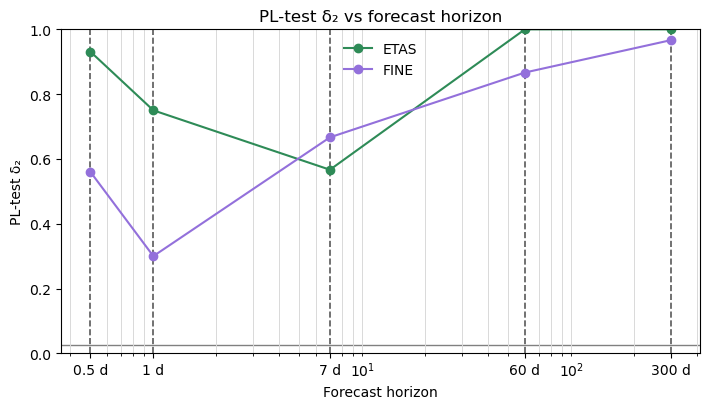

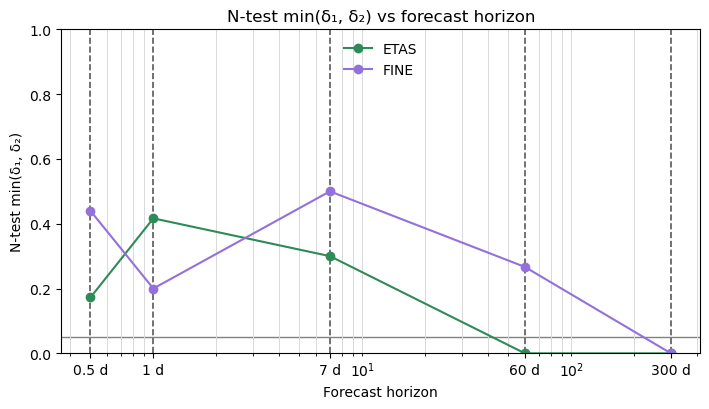

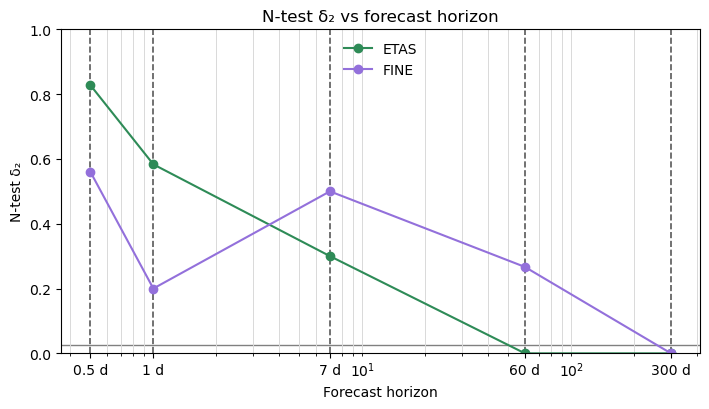

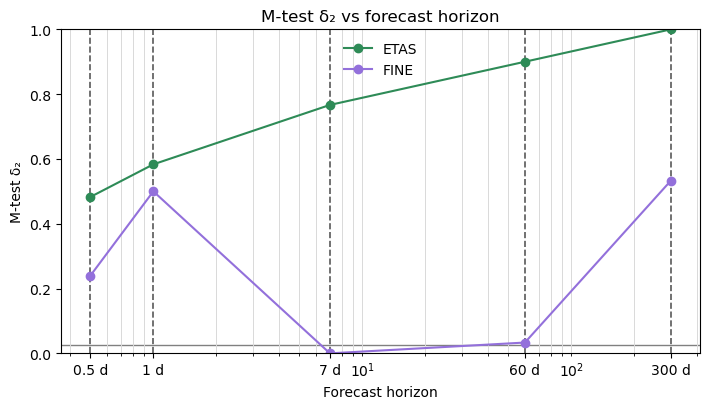

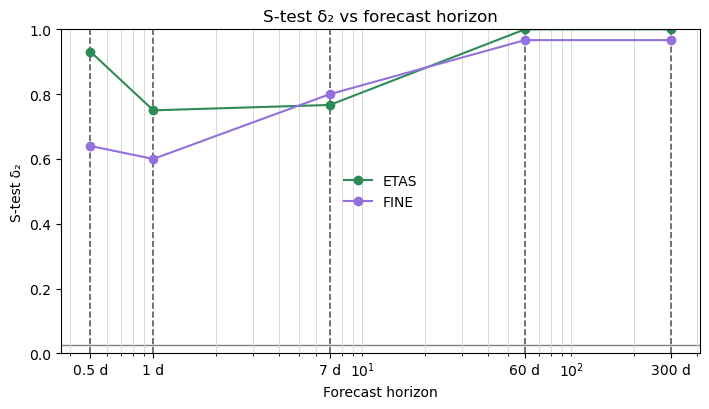

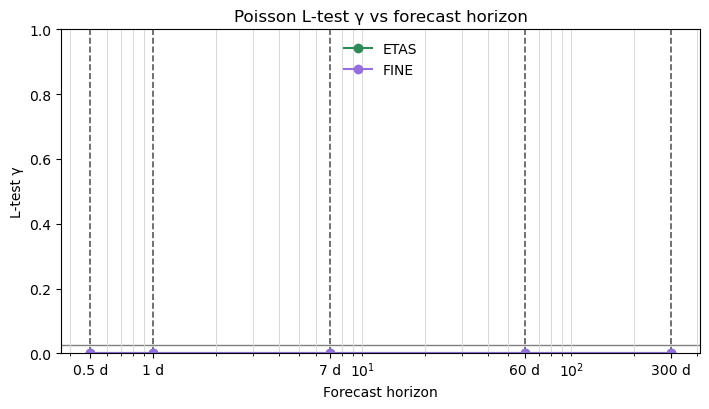

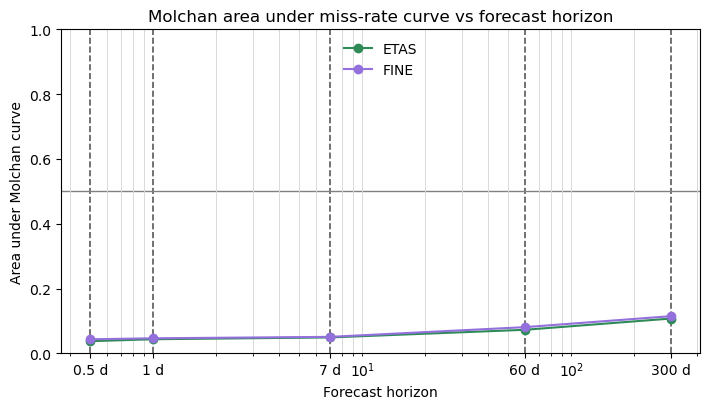

In [6]:
def _csep_time_frame(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if "time" not in out.columns and "time_days" in out.columns:
        out["time"] = (
            pd.Timestamp("1970-01-01") + pd.to_timedelta(out["time_days"], unit="D")
        )
    return out


def build_csep_molchan_horizon_table(
    *,
    l_test_simulations: int = BAYONA_N_SIM,
) -> pd.DataFrame:
    """PL / N / M / S / Poisson L and Molchan area for each horizon and method."""
    rows: list[dict] = []
    for experiment in EXPERIMENTS:
        comparison = horizon_comparison.load_comparison(experiment["output_root"])
        for days in experiment["horizon_days"]:
            days = float(days)
            try:
                store = comparison.analysis(days)
            except FileNotFoundError:
                display(Markdown(f"*Skipped CSEP/Molchan at {days:g} d: no analysis cache.*"))
                continue
            if not store.seeds:
                display(Markdown(f"*Skipped CSEP/Molchan at {days:g} d: no cached seeds.*"))
                continue
            windows = store.windows()
            if windows.empty:
                continue
            region, study_poly, fit = store.forecast_region()
            m_ref = float(fit["m_ref"])
            span_start = windows["forecast_start"].min().to_pydatetime()
            span_end = windows["forecast_end"].max().to_pydatetime()
            observed = csep_utils.filter_to_csep_region(
                _csep_time_frame(store.observed_frame()),
                region=region,
                m_ref=m_ref,
                study_poly=study_poly,
            )
            observed_csep = csep_utils.dataframe_to_csep_catalog(
                observed, catalog_id=int(round(10 * days)), region=region,
            )
            if observed_csep.event_count < 1:
                display(Markdown(
                    f"*Skipped CSEP/Molchan at {days:g} d: empty observed catalog.*"
                ))
                continue
            print(
                f"CSEP/Molchan T={days:g} d: {len(store.seeds)} seeds, "
                f"{observed_csep.event_count} observed events",
                flush=True,
            )
            for method in METHODS:
                if method not in store.methods:
                    continue
                catalogs = [
                    _csep_time_frame(store.event_frame(method, seed))
                    for seed in store.seeds
                ]
                forecast = csep_utils.build_catalog_forecast_from_dataframes(
                    catalogs,
                    name=METHOD_LABELS.get(method, method),
                    region=region,
                    start_time=span_start,
                    end_time=span_end,
                    m_ref=m_ref,
                    study_poly=study_poly,
                )
                if forecast is None:
                    display(Markdown(
                        f"*Skipped {METHOD_LABELS.get(method, method)} at {days:g} d: "
                        "no non-empty forecast catalogs.*"
                    ))
                    continue
                scores = csep_utils.run_csep_catalog_tests(
                    forecast,
                    observed_csep,
                    include_l_test=True,
                    l_test_simulations=l_test_simulations,
                    l_test_seed=int(round(10 * days)),
                )
                csep_utils.pop_csep_sim_arrays(scores)
                try:
                    molchan = csep_utils.molchan_from_catalog_forecast(
                        forecast, observed_csep,
                    )
                    molchan_auc = float(molchan.area_under_curve)
                    molchan_ass = float(molchan.area_skill_score)
                except ValueError as exc:
                    display(Markdown(
                        f"*Molchan failed for {METHOD_LABELS.get(method, method)} "
                        f"at {days:g} d: {exc}*"
                    ))
                    molchan_auc = float("nan")
                    molchan_ass = float("nan")
                rows.append({
                    "horizon_days": days,
                    "method": method,
                    "n_seeds": len(store.seeds),
                    "n_observed": float(scores["n_observed"]),
                    "n_forecast": float(scores["n_forecast"]),
                    "PL_delta": float(scores["L_delta2"]),
                    "N_delta": float(min(scores["N_delta1"], scores["N_delta2"])),
                    "N_delta2": float(scores["N_delta2"]),
                    "M_delta": float(scores["M_delta2"]),
                    "S_delta": float(scores["S_delta2"]),
                    "L_delta": float(scores["Ltest_gamma"]),
                    "molchan_auc": molchan_auc,
                    "molchan_ass": molchan_ass,
                })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["horizon_days", "method"]).reset_index(drop=True)


csep_molchan_horizon = build_csep_molchan_horizon_table()
display(csep_molchan_horizon)

csep_molchan_specs = [
    {
        "metric": "PL_delta",
        "title": "PL-test δ₂ vs forecast horizon",
        "ylabel": "PL-test δ₂",
        "hline": 0.025,
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "N_delta",
        "title": "N-test min(δ₁, δ₂) vs forecast horizon",
        "ylabel": "N-test min(δ₁, δ₂)",
        "hline": 0.05,
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "N_delta2",
        "title": "N-test δ₂ vs forecast horizon",
        "ylabel": "N-test δ₂",
        "hline": 0.025,
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "M_delta",
        "title": "M-test δ₂ vs forecast horizon",
        "ylabel": "M-test δ₂",
        "hline": 0.025,
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "S_delta",
        "title": "S-test δ₂ vs forecast horizon",
        "ylabel": "S-test δ₂",
        "hline": 0.025,
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "L_delta",
        "title": "Poisson L-test γ vs forecast horizon",
        "ylabel": "L-test γ",
        "hline": 0.025,
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "molchan_auc",
        "title": "Molchan area under miss-rate curve vs forecast horizon",
        "ylabel": "Area under Molchan curve",
        "hline": 0.5,
        "ylim": (0.0, 1.0),
    },
]

if csep_molchan_horizon.empty:
    display(Markdown("*No CSEP / Molchan horizon rows to plot.*"))
else:
    for spec in csep_molchan_specs:
        plot_metric_vs_horizon(
            csep_molchan_horizon,
            spec["metric"],
            title=spec["title"],
            ylabel=spec["ylabel"],
            ylim=spec.get("ylim"),
            hline=spec.get("hline"),
        )


### Direct PyCSEP `matrix_binary_t_test`

Call `csep.core.binomial_evaluations.matrix_binary_t_test` on each horizon's pooled FINE / ETAS grids. Results are kept in `matrix_binary_t_results` (list of dicts, one per horizon) for exploration.


,horizon_days,information_gain,ig_lower,ig_upper,t_statistic,t_critical,n_active_bins,n_observed,n_forecast_FINE,n_forecast_etas,significant
0,0.5,-0.146678,-0.201895,-0.091460,-5.214331,1.962975,790,1088,3757.423721,2052.705449,True
1,1.0,1.779117,1.720063,1.838171,59.138593,1.962975,790,1088,3146.247503,3110.545358,True
2,7.0,-0.182837,-0.217362,-0.148313,-10.395623,1.962975,790,1088,974.806271,909.672914,True
3,60.0,-0.348711,-0.390817,-0.306605,-16.256871,1.962975,790,1088,1151.422408,929.083122,True
4,300.0,-0.075968,-0.134072,-0.017863,-2.566435,1.962975,790,1088,1072.704722,1067.194505,True


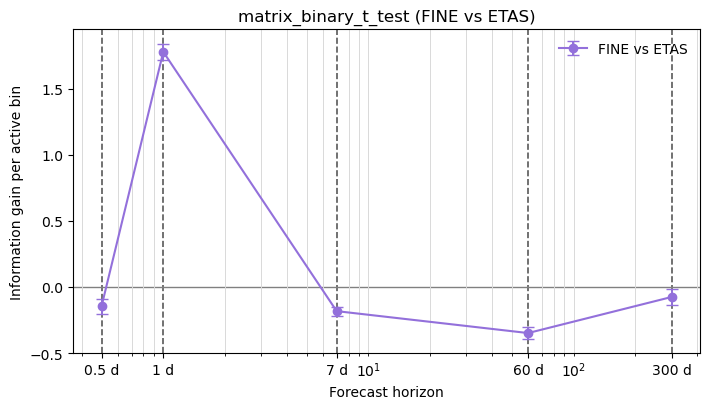

,horizon_days,information_gain_wrapper,information_gain_matrix,ig_diff,ig_lower_wrapper,ig_lower_matrix,ig_upper_wrapper,ig_upper_matrix
0,0.5,-0.146678,-0.146678,0.0,-0.201895,-0.201895,-0.091460,-0.091460
1,1.0,1.779117,1.779117,0.0,1.720063,1.720063,1.838171,1.838171
2,7.0,-0.182837,-0.182837,0.0,-0.217362,-0.217362,-0.148313,-0.148313
3,60.0,-0.348711,-0.348711,0.0,-0.390817,-0.390817,-0.306605,-0.306605
4,300.0,-0.075968,-0.075968,0.0,-0.134072,-0.134072,-0.017863,-0.017863


In [7]:
def build_matrix_binary_t_table() -> pd.DataFrame:
    """Horizon-level matrix_binary_t_test of FINE against ETAS (no wrapper)."""
    rows: list[dict] = []
    for experiment in EXPERIMENTS:
        comparison = horizon_comparison.load_comparison(experiment["output_root"])
        for days in experiment["horizon_days"]:
            days = float(days)
            try:
                store = comparison.analysis(days)
            except FileNotFoundError:
                continue
            if "FINE" not in store.methods or "etas" not in store.methods:
                continue
            rates = store.mean_rate_grid()
            if "FINE" not in rates or "etas" not in rates:
                display(Markdown(
                    f"*Skipped matrix_binary_t_test at {days:g} d: missing mean rate grids.*"
                ))
                continue
            windows = store.windows()
            if windows.empty:
                continue
            region, study_poly, fit = store.forecast_region()
            start = windows["forecast_start"].min().to_pydatetime()
            end = windows["forecast_end"].max().to_pydatetime()
            forecast_fine = csep_utils.gridded_forecast_from_rates(
                rates["FINE"], region, start, end, METHOD_LABELS.get("FINE", "FINE"),
            )
            forecast_etas = csep_utils.gridded_forecast_from_rates(
                rates["etas"], region, start, end, METHOD_LABELS.get("etas", "ETAS"),
            )
            observed = store.observed_frame().copy()
            if "time" not in observed.columns and "time_days" in observed.columns:
                observed["time"] = (
                    pd.Timestamp("1970-01-01")
                    + pd.to_timedelta(observed["time_days"], unit="D")
                )
            observed = csep_utils.filter_to_csep_region(
                observed,
                region=region,
                m_ref=float(fit["m_ref"]),
                study_poly=study_poly,
            )
            observed_catalog = csep_utils.dataframe_to_csep_catalog(
                observed, catalog_id=int(round(10 * days)), region=region,
            )
            active = np.unique(
                np.nonzero(observed_catalog.spatial_magnitude_counts().ravel())[0]
            )
            if active.size < 2:
                display(Markdown(
                    f"*Skipped matrix_binary_t_test at {days:g} d: "
                    f"only {active.size} active bins.*"
                ))
                continue
            # Active-bin rates (X1, X2) and full-grid totals (N1, N2).
            rates_fine = np.asarray(forecast_fine.data, dtype=float).ravel()[active]
            rates_etas = np.asarray(forecast_etas.data, dtype=float).ravel()[active]
            n_f_fine = float(forecast_fine.event_count)
            n_f_etas = float(forecast_etas.event_count)
            out = binomial_evaluations.matrix_binary_t_test(
                rates_fine,
                rates_etas,
                observed_catalog.event_count,
                n_f_fine,
                n_f_etas,
                observed_catalog,
            )
            rows.append({
                "horizon_days": days,
                "information_gain": float(out["information_gain"]),
                "ig_lower": float(out["ig_lower"]),
                "ig_upper": float(out["ig_upper"]),
                "t_statistic": float(out["t_statistic"]),
                "t_critical": float(out["t_critical"]),
                "n_active_bins": int(active.size),
                "n_observed": int(observed_catalog.event_count),
                "n_forecast_FINE": n_f_fine,
                "n_forecast_etas": n_f_etas,
                "significant": bool(out["ig_lower"] > 0.0 or out["ig_upper"] < 0.0),
            })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("horizon_days").reset_index(drop=True)


matrix_binary_t = build_matrix_binary_t_table()
display(matrix_binary_t)
plot_binary_paired_t_vs_horizon(
    matrix_binary_t,
    title="matrix_binary_t_test (FINE vs ETAS)",
)

if not binary_paired_t.empty and not matrix_binary_t.empty:
    compare = binary_paired_t.merge(
        matrix_binary_t,
        on="horizon_days",
        suffixes=("_wrapper", "_matrix"),
    )
    compare["ig_diff"] = (
        compare["information_gain_wrapper"] - compare["information_gain_matrix"]
    )
    display(compare[[
        "horizon_days",
        "information_gain_wrapper",
        "information_gain_matrix",
        "ig_diff",
        "ig_lower_wrapper",
        "ig_lower_matrix",
        "ig_upper_wrapper",
        "ig_upper_matrix",
    ]])


In [8]:
display(cumulative_number)
display(plot_summary.sort_values(["horizon_days", "method"]).reset_index(drop=True))
display(binary_paired_t)
if "matrix_binary_t_results" in globals():
    display(matrix_binary_t_results)
else:
    display(Markdown("*Run the `matrix_binary_t_test` cell above to populate `matrix_binary_t_results`.*"))


,horizon_days,method,n_forecast,n_observed,delta_percent,poisson_low,poisson_high,nbd_low,nbd_high,catalog_variance
0,0.5,FINE,3757.423721,1088.0,71.043990,3638.0,3878.0,5.0,18451.0,2.685809e+07
1,0.5,etas,2052.705449,1088.0,46.996779,1964.0,2142.0,1070.0,3348.0,3.424806e+05
2,1.0,FINE,3146.247503,1088.0,65.419122,3037.0,3257.0,24.0,13323.0,1.355971e+07
3,1.0,etas,3110.545358,1088.0,65.022211,3002.0,3220.0,2094.0,4324.0,3.253048e+05
4,7.0,FINE,974.806271,1088.0,10.403835,914.0,1036.0,74.0,3002.0,6.150068e+05
5,7.0,etas,909.672914,1088.0,16.390357,851.0,969.0,417.0,1589.0,9.099334e+04
6,60.0,FINE,1151.422408,1088.0,5.508179,1085.0,1218.0,63.0,3772.0,1.000175e+06
7,60.0,etas,929.083122,1088.0,14.606331,870.0,989.0,666.0,1234.0,2.105851e+04
8,300.0,FINE,1072.704722,1088.0,1.405816,1009.0,1137.0,186.0,2719.0,4.444291e+05
9,300.0,etas,1067.194505,1088.0,1.912270,1004.0,1132.0,815.0,1352.0,1.884077e+04


,horizon_days,method,n_windows,n_seeds,total_forecast,total_observed,mean_delta_percent,mean_zeta,fraction_zeta_ge_0.05,mean_igpa,fraction_poisson_consistent_95,fraction_nbd_consistent_95,fraction_binary_cl_consistent_95,n_steps_cached,n_steps_on_disk,mean_n_forecast,mean_n_observed,zeta_calibration_area,zeta_ks_pvalue,cumulative_igpa
0,0.5,FINE,2267,29,3757.423721,1088.0,79.442882,0.214966,0.845013,0.695879,0.986326,0.994707,0.945743,2267,2267,1.657443,0.479929,0.286234,2.040234e-173,146.134628
1,0.5,etas,2267,29,2052.705449,1088.0,76.773826,0.129818,0.850404,NaN,0.989413,0.318483,0.924129,2267,2267,0.905472,0.479929,0.370197,5.335909e-322,NaN
2,1.0,FINE,1134,12,3146.247503,1088.0,71.494770,0.172878,0.777961,0.835123,0.914462,0.974427,0.875661,1134,1134,2.774469,0.959436,0.327307,8.788812e-174,209.615823
3,1.0,etas,1134,12,3110.545358,1088.0,71.752844,0.069457,0.574013,NaN,0.970018,0.206349,0.745150,1134,1134,2.742985,0.959436,0.430127,0.000000e+00,NaN
4,7.0,FINE,162,30,974.806271,1088.0,36.510424,0.156180,0.596273,-0.178313,0.808642,0.962963,0.629630,162,162,6.017323,6.716049,0.343618,2.124416e-51,-27.638558
5,7.0,etas,162,30,909.672914,1088.0,36.899609,0.201149,0.701863,NaN,0.827160,0.962963,0.728395,162,162,5.615265,6.716049,0.298634,2.674129e-30,NaN
6,60.0,FINE,19,30,1151.422408,1088.0,21.607751,0.001842,0.000000,-0.288169,0.631579,1.000000,0.000000,19,19,60.601179,57.263158,0.472632,2.324523e-29,-5.475211
7,60.0,etas,19,30,929.083122,1088.0,24.005854,0.011842,0.052632,NaN,0.421053,0.947368,0.052632,19,19,48.899112,57.263158,0.463421,1.218719e-23,NaN
8,300.0,FINE,4,30,1072.704722,1088.0,12.914224,0.000000,0.000000,-0.111467,0.250000,1.000000,0.000000,4,4,268.176181,272.000000,0.375000,0.000000e+00,-0.445870
9,300.0,etas,4,30,1067.194505,1088.0,16.256170,0.001250,0.000000,NaN,0.250000,1.000000,0.000000,4,4,266.798626,272.000000,0.374375,1.250000e-09,NaN


,horizon_days,information_gain,ig_lower,ig_upper,t_statistic,t_critical,n_observed,n_forecast_FINE,n_forecast_etas,significant
0,0.5,-0.146678,-0.201895,-0.091460,-5.214331,1.962975,1088,3757.423721,2052.705449,True
1,1.0,1.779117,1.720063,1.838171,59.138593,1.962975,1088,3146.247503,3110.545358,True
2,7.0,-0.182837,-0.217362,-0.148313,-10.395623,1.962975,1088,974.806271,909.672914,True
3,60.0,-0.348711,-0.390817,-0.306605,-16.256871,1.962975,1088,1151.422408,929.083122,True
4,300.0,-0.075968,-0.134072,-0.017863,-2.566435,1.962975,1088,1072.704722,1067.194505,True


*Run the `matrix_binary_t_test` cell above to populate `matrix_binary_t_results`.*

## Space-time log-likelihood vs horizon

Each forecast point is the mean, across seeds, of the sum of that seed's window log-likelihoods. The shaded band is one standard deviation on either side of that mean. The black line is the sum of the observed test-window log-likelihoods for the same windows. Training windows are left out: each one is the growing fitting catalog, so those values are a different interval.

The observed test score does not depend on ETAS versus FINE, because both use the same space-time intensity on the observed catalog. A horizon appears only when `analysis_cache/spacetime_loglikelihood.csv` (or the same file next to the horizon) already exists. Fill a missing horizon from `spacetime_loglikelihood.ipynb` or `runnable_code/cache_rolling_analysis.py`.

No space-time log-likelihood table yet for 0.5 d. Those horizons are left off the figure.

,horizon_days,method,n_seeds,mean_log_likelihood,std_log_likelihood,observed_test_log_likelihood
0,1.0,FINE,12,-18487.801666,17316.848166,-10170.369986
1,1.0,etas,12,-12336.546720,7649.063093,-10170.369986
2,7.0,FINE,30,-11128.677477,5031.267308,-10164.243669
3,7.0,etas,30,-10910.556223,3009.712473,-10164.243669
4,60.0,FINE,30,-11714.926611,5296.309800,-10165.245988
5,60.0,etas,30,-11073.063717,1189.554414,-10165.245988
6,300.0,FINE,30,-12117.658680,3653.863537,-10169.221955
7,300.0,etas,30,-11785.573829,933.674428,-10169.221955


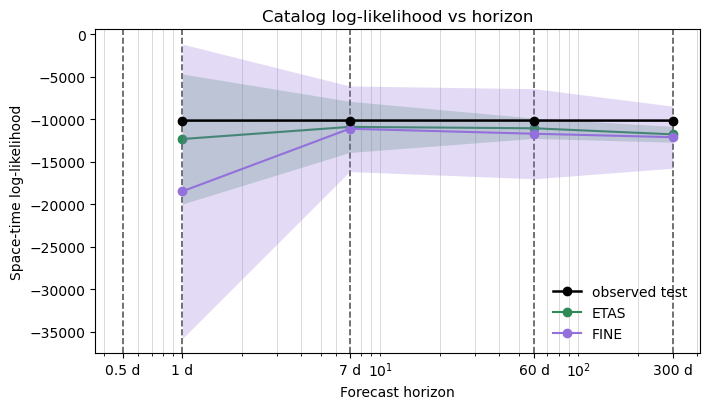

In [9]:
def _spacetime_ll_path(horizon_dir: Path) -> Path | None:
    for candidate in (
        horizon_dir / "analysis_cache" / "spacetime_loglikelihood.csv",
        horizon_dir / "spacetime_loglikelihood.csv",
    ):
        if candidate.is_file():
            return candidate
    return None


ll_rows = []
missing_horizons = []
for experiment in EXPERIMENTS:
    for days in experiment["horizon_days"]:
        horizon_dir = rolling_analysis.horizon_directory(experiment["output_root"], float(days))
        path = _spacetime_ll_path(horizon_dir)
        if path is None:
            missing_horizons.append(f"{float(days):g} d")
            continue
        frame = pd.read_csv(path)
        observed_total = float(frame.loc[frame["kind"] == "observed_test", "log_likelihood"].sum())
        forecasts = frame.loc[frame["kind"] == "forecast"]
        for method, group in forecasts.groupby("method"):
            totals = group.groupby("seed")["log_likelihood"].sum()
            ll_rows.append({
                "horizon_days": float(days),
                "method": str(method),
                "n_seeds": int(totals.shape[0]),
                "mean_log_likelihood": float(totals.mean()),
                "std_log_likelihood": float(totals.std(ddof=1)) if len(totals) > 1 else 0.0,
                "observed_test_log_likelihood": observed_total,
            })

spacetime_ll = (
    pd.DataFrame(ll_rows)
    .sort_values(["horizon_days", "method"])
    .reset_index(drop=True)
)
if missing_horizons:
    display(Markdown(
        "No space-time log-likelihood table yet for "
        + ", ".join(missing_horizons)
        + ". Those horizons are left off the figure."
    ))
display(spacetime_ll)


def plot_spacetime_ll_vs_horizon(table: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    _style_horizon_axis(ax)
    observed = table.drop_duplicates("horizon_days").sort_values("horizon_days")
    ax.plot(
        observed["horizon_days"],
        observed["observed_test_log_likelihood"],
        color="black",
        marker="o",
        linewidth=1.8,
        label="observed test",
        zorder=3,
    )
    for method in methods:
        part = table.loc[table["method"] == method].sort_values("horizon_days")
        if part.empty:
            continue
        x = part["horizon_days"].to_numpy(dtype=float)
        mean = part["mean_log_likelihood"].to_numpy(dtype=float)
        std = part["std_log_likelihood"].to_numpy(dtype=float)
        color = METHOD_COLORS.get(method)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.25, linewidth=0, zorder=2)
        ax.plot(
            x,
            mean,
            color=color,
            marker="o",
            label=METHOD_LABELS.get(method, method),
            zorder=2,
        )
    ax.set_ylabel("Space-time log-likelihood")
    ax.set_title("Catalog log-likelihood vs horizon")
    ax.legend(frameon=False)
    fig.tight_layout()
    show_fig(fig)


plot_spacetime_ll_vs_horizon(spacetime_ll)


## Magnitude log-likelihood vs horizon

Each forecast point is the mean, across seeds, of the mean \(\log p(m)\) inside that seed. FINE uses the MAGNET density and ETAS uses the Gutenberg–Richter density of the window that contains the event. The shaded band is one standard deviation on either side of that mean. The dashed line is the mean \(\log p(m)\) of the observed test catalog under that model.

A horizon appears only when `analysis_cache/magnitude_likelihoods.csv` is finished. Fill a missing horizon with `runnable_code/cache_rolling_analysis.py`.

No finished magnitude-likelihood table yet for 0.5 d, 1 d. Those horizons are left off the figure.

,horizon_days,method,n_seeds,mean_log_likelihood,std_log_likelihood,observed_test_log_likelihood
0,7.0,FINE,30,-204.164543,590.658697,-881.372855
1,7.0,etas,30,-421.650058,202.105098,-1047.809867
2,60.0,FINE,30,-359.767157,794.946808,-881.372855
3,60.0,etas,30,-421.733756,105.438902,-1047.729052
4,300.0,FINE,30,-303.213882,411.051594,-881.372855
5,300.0,etas,30,-460.276898,76.379730,-1047.641572


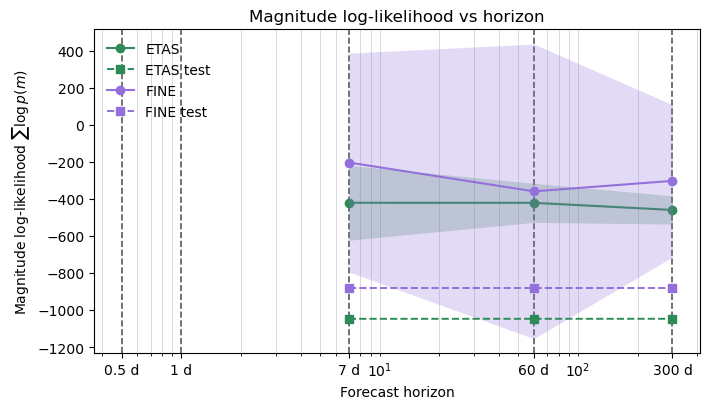

In [10]:
_MAGNITUDE_DENSITY = {"etas": "etas_likelihood", "FINE": "fine_likelihood"}


def _mean_log_density(density: pd.Series | np.ndarray) -> float:
    values = np.log(np.asarray(density, dtype=float))
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return float(values.mean())


magnitude_rows = []
missing_magnitude = []
for experiment in EXPERIMENTS:
    for days in experiment["horizon_days"]:
        horizon_dir = rolling_analysis.horizon_directory(experiment["output_root"], float(days))
        csv_path = horizon_dir / "analysis_cache" / "magnitude_likelihoods.csv"
        if not csv_path.is_file():
            missing_magnitude.append(f"{float(days):g} d")
            continue
        frame = pd.read_csv(csv_path)
        observed = frame.loc[
            (frame["population"] == "test") & (frame["source"] == "observed")
        ]
        forecasts = frame.loc[frame["population"] == "forecast"]
        for method in methods:
            column = _MAGNITUDE_DENSITY[method]
            per_seed = np.array([
                _mean_log_density(group[column])
                for _seed, group in forecasts.loc[forecasts["source"] == method].groupby("seed")
            ], dtype=float)
            per_seed = per_seed[np.isfinite(per_seed)]
            magnitude_rows.append({
                "horizon_days": float(days),
                "method": method,
                "n_seeds": int(per_seed.size),
                "mean_log_likelihood": float(per_seed.mean()) if per_seed.size else np.nan,
                "std_log_likelihood": float(per_seed.std(ddof=1)) if per_seed.size > 1 else 0.0,
                "observed_test_log_likelihood": _mean_log_density(observed[column]),
            })

magnitude_ll = (
    pd.DataFrame(magnitude_rows)
    .sort_values(["horizon_days", "method"])
    .reset_index(drop=True)
)
if missing_magnitude:
    display(Markdown(
        "No finished magnitude-likelihood table yet for "
        + ", ".join(missing_magnitude)
        + ". Those horizons are left off the figure."
    ))
display(magnitude_ll)


def plot_magnitude_ll_vs_horizon(table: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    _style_horizon_axis(ax)
    for method in methods:
        part = table.loc[table["method"] == method].sort_values("horizon_days")
        if part.empty:
            continue
        x = part["horizon_days"].to_numpy(dtype=float)
        mean = part["mean_log_likelihood"].to_numpy(dtype=float)
        std = part["std_log_likelihood"].to_numpy(dtype=float)
        color = METHOD_COLORS.get(method)
        label = METHOD_LABELS.get(method, method)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.25, linewidth=0, zorder=2)
        ax.plot(x, mean, color=color, marker="o", label=label, zorder=2)
        ax.plot(
            x,
            part["observed_test_log_likelihood"],
            color=color,
            marker="s",
            linestyle="--",
            linewidth=1.4,
            label=f"{label} test",
            zorder=3,
        )
    ax.set_ylabel("Mean magnitude log-likelihood")
    ax.set_title("Magnitude log-likelihood vs horizon")
    ax.legend(frameon=False)
    fig.tight_layout()
    show_fig(fig)


plot_magnitude_ll_vs_horizon(magnitude_ll)
